# HW2 Image Classification

Submit this Jupyter notebook with the code outputs, along with the report.
Ensure that the best accuracy score achieved is mentioned in the report.

# Check GPU Type

In [1]:
!nvidia-smi

Sat Sep 26 04:21:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
def get_device():
    ''' Get device (if GPU is available, use GPU) '''
    return 'cuda' if torch.cuda.is_available() else 'cpu'

import torch
print(get_device())
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
True
Tesla T4


# Get Data
Notes: if the links are dead, you can download the data directly from Kaggle and upload it to the workspace, or you can use the Kaggle API to directly download the data into colab.


In [3]:
# Download Link
# Link 1 (Dropbox): https://www.dropbox.com/s/up5q1gthsz3v0dq/food-11.zip?dl=0
# Link 2 (Google Drive): https://drive.google.com/file/d/1tbGNwk1yGoCBdu4Gi_Cia7EJ9OhubYD9/view?usp=share_link

!ln -s /kaggle/input/hw2-food11-data/train ./train
!ln -s /kaggle/input/hw2-food11-data/valid ./valid
!ln -s /kaggle/input/hw2-food11-data/test ./test

# !curl -L -o food11.zip "https://www.dropbox.com/s/up5q1gthsz3v0dq/food-11.zip?dl=1"

# !pip install gdown --upgrade
# !gdown '1tbGNwk1yGoCBdu4Gi_Cia7EJ9OhubYD9' -O food11.zip

# Import Packages

In [4]:
_exp_name = "exp_15"

In [5]:
# Import necessary packages.
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
# This is for the progress bar.
from tqdm.auto import tqdm
import random

In [6]:
myseed = 6666  # set a random seed for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms
Torchvision provides lots of useful utilities for image preprocessing, data *wrapping* as well as data augmentation.

Please refer to PyTorch official website for details about different transforms.

In [7]:
test_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_tfm = transforms.Compose([
    # RandomResizedCrop resizes to a fixed shape (128x128) while also randomly
    # cropping a sub-region first, so it replaces the plain Resize() and adds
    # scale/aspect-ratio augmentation in one step.
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),

    # ToTensor() should be the last one of the transforms.
    transforms.ToTensor(),
])


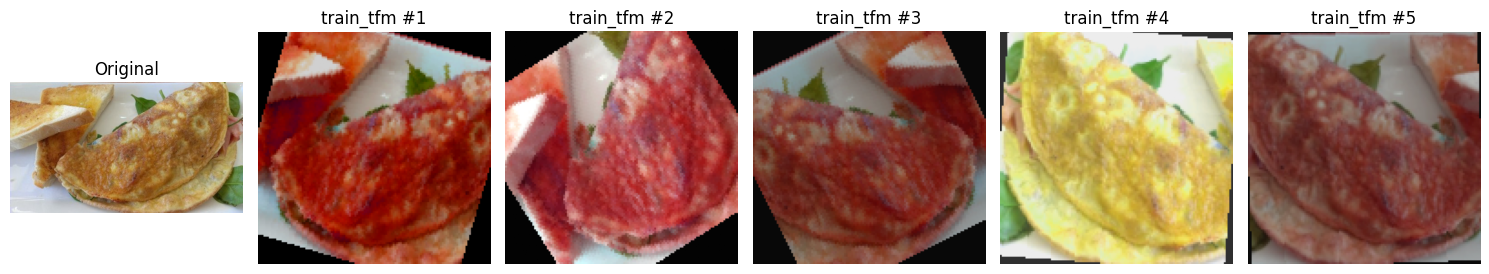

In [8]:
# apply train_tfm
import matplotlib.pyplot as plt

sample_path = sorted(os.path.join("./train", x) for x in os.listdir("./train") if x.endswith(".jpg"))[0]
sample_img = Image.open(sample_path)

n_samples = 5
fig, axes = plt.subplots(1, n_samples + 1, figsize=((n_samples + 1) * 2.5, 3))

axes[0].imshow(sample_img)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(n_samples):
    augmented = train_tfm(sample_img)  # CxHxW tensor in [0,1]
    axes[i + 1].imshow(augmented.permute(1, 2, 0))
    axes[i + 1].set_title(f"train_tfm #{i+1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.savefig("q1_augmentation_grid.png", dpi=150)
plt.show()

# Datasets
The data is labelled by the name, so we load images and label while calling '__getitem__'

In [9]:
class FoodDataset(Dataset):

    def __init__(self,path,tfm=test_tfm,files = None):
        super(FoodDataset).__init__()
        self.path = path
        self.files = sorted([os.path.join(path,x) for x in os.listdir(path) if x.endswith(".jpg")])
        if files != None:
            self.files = files

        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)

        try:
            label = int(os.path.basename(fname).split("_")[0])
        except:
            # test has no label
            label = -1

        return im,label

# Model

In [10]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        # torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        # torch.nn.MaxPool2d(kernel_size, stride, padding)
        # input dimension [3, 128, 128]
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),  # [64, 128, 128]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),      # [64, 64, 64]

            nn.Conv2d(64, 128, 3, 1, 1), # [128, 64, 64]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),      # [128, 32, 32]

            nn.Conv2d(128, 256, 3, 1, 1), # [256, 32, 32]
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),      # [256, 16, 16]

            nn.Conv2d(256, 512, 3, 1, 1), # [512, 16, 16]
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),       # [512, 8, 8]

            nn.Conv2d(512, 512, 3, 1, 1), # [512, 8, 8]
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2, 0),       # [512, 4, 4]
        )
        self.fc = nn.Sequential(
            nn.Linear(512*4*4, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 11)
        )

    def forward(self, x):
        out = self.cnn(x)
        out = out.view(out.size()[0], -1)
        return self.fc(out)

In [11]:
import torchvision.models as models

def build_model(arch, num_classes=11, dropout_p=0.5):
    if arch == "resnet34":
        model = models.resnet34(weights=None)
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(model.fc.in_features, num_classes),
        )
    elif arch == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(model.fc.in_features, num_classes),
        )
    elif arch == "densenet121":
        model = models.densenet121(weights=None)
        model.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(model.classifier.in_features, num_classes),
        )
    elif arch == "vgg16_bn":
        model = models.vgg16_bn(weights=None)
        model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    else:
        raise ValueError(f"unknown arch: {arch}")
    return model

# Configurations

In [12]:
# "cuda" only when GPUs are available.
device = "cuda" if torch.cuda.is_available() else "cpu"

# The number of batch size
batch_size = 64

# The number of training epochs
n_epochs = 150

# If no improvement within patience # of epochs, stop early
patience = 25

# cross-entropy loss
criterion = nn.CrossEntropyLoss()

model = build_model("vgg16_bn").to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

cutmix_prob = 0.5
cutmix_beta_alpha = 1.0

checkpoint_input_dir = "/kaggle/input/hw2-checkpoints" if os.path.isdir("/kaggle/input/hw2-checkpoints") else "."

# Dataloader

In [13]:
train_set = FoodDataset("./train", tfm=train_tfm)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
valid_set = FoodDataset("./valid", tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)

# Start Training

In [14]:
RUN_TRAINING = True
model_save_path = os.path.join(checkpoint_input_dir, "exp_15_best.ckpt") if not RUN_TRAINING else f"{_exp_name}_best.ckpt"
log_path = f"{_exp_name}_log.txt"

def rand_bbox(width, height, lam):
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(width * cut_rat)
    cut_h = int(height * cut_rat)
    cx = np.random.randint(width)
    cy = np.random.randint(height)
    x1 = np.clip(cx - cut_w // 2, 0, width)
    y1 = np.clip(cy - cut_h // 2, 0, height)
    x2 = np.clip(cx + cut_w // 2, 0, width)
    y2 = np.clip(cy + cut_h // 2, 0, height)
    return x1, y1, x2, y2

if RUN_TRAINING:
    stale = 0
    best_acc = -1.0

    for epoch in range(n_epochs):
        model.train()
        train_loss = []
        train_accs = []

        for imgs, labels in tqdm(train_loader):
            imgs, labels = imgs.to(device), labels.to(device)

            if np.random.rand() < cutmix_prob:
                lam = np.random.beta(cutmix_beta_alpha, cutmix_beta_alpha)
                rand_index = torch.randperm(imgs.size(0)).to(device)
                labels_b = labels[rand_index]
                x1, y1, x2, y2 = rand_bbox(imgs.size(3), imgs.size(2), lam)
                imgs[:, :, y1:y2, x1:x2] = imgs[rand_index, :, y1:y2, x1:x2]
                lam = 1 - ((x2 - x1) * (y2 - y1) / (imgs.size(-1) * imgs.size(-2)))
                logits = model(imgs)
                loss = lam * criterion(logits, labels) + (1 - lam) * criterion(logits, labels_b)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
            optimizer.step()

            acc = (logits.argmax(dim=-1) == labels).float().mean()
            train_loss.append(loss.item())
            train_accs.append(acc.item())

        train_loss = sum(train_loss) / len(train_loss)
        train_acc = sum(train_accs) / len(train_accs)
        print(f"[ Train | {epoch + 1:03d}/{n_epochs:03d} ] loss = {train_loss:.5f}, acc = {train_acc:.5f}")

        model.eval()
        valid_loss = []
        valid_accs = []
        for imgs, labels in tqdm(valid_loader):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                logits = model(imgs)
            loss = criterion(logits, labels)
            acc = (logits.argmax(dim=-1) == labels).float().mean()
            valid_loss.append(loss.item())
            valid_accs.append(acc.item())

        valid_loss = sum(valid_loss) / len(valid_loss)
        valid_acc = sum(valid_accs) / len(valid_accs)
        current_lr = optimizer.param_groups[0]["lr"]
        log_line = f"[ Valid | {epoch + 1:03d}/{n_epochs:03d} ] loss = {valid_loss:.5f}, acc = {valid_acc:.5f}, lr = {current_lr:.6f}"

        if valid_acc > best_acc:
            print(f"Best model found at epoch {epoch}, saving model")
            torch.save(model.state_dict(), model_save_path)
            best_acc = valid_acc
            stale = 0
            log_line += " -> best"
        else:
            stale += 1

        print(log_line)
        with open(log_path, "a") as f:
            f.write(log_line + "\n")

        if stale > patience:
            print(f"No improvement in {patience} consecutive epochs, early stopping")
            break

        scheduler.step()
else:
    print(f"Reusing existing checkpoint at {model_save_path}")

  0%|          | 0/157 [00:00<?, ?it/s]

[ Train | 001/150 ] loss = 2.86624, acc = 0.15396


  0%|          | 0/57 [00:00<?, ?it/s]

Best model found at epoch 0, saving model
[ Valid | 001/150 ] loss = 2.22813, acc = 0.19568, lr = 0.000300 -> best


  0%|          | 0/157 [00:00<?, ?it/s]

...

[ Valid | 149/150 ] loss = 0.56320, acc = 0.82899, lr = 0.000000


  0%|          | 0/157 [00:00<?, ?it/s]

[ Train | 150/150 ] loss = 0.76048, acc = 0.77737


  0%|          | 0/57 [00:00<?, ?it/s]

[ Valid | 150/150 ] loss = 0.54659, acc = 0.82789, lr = 0.000000


In [15]:
# 4-model ensemble evaluation on the validation set
n_tta_passes = 5

def tta_predict_probs(model, base_path, n_passes=n_tta_passes):
    """Returns TTA-blended softmax probabilities (0.2*avg(train_tfm) + 0.8*test_tfm)
    for every image in base_path, in FoodDataset's sorted file order."""
    model.eval()
    plain_loader = DataLoader(FoodDataset(base_path, tfm=test_tfm), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    aug_loader = DataLoader(FoodDataset(base_path, tfm=train_tfm), batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    plain_probs = []
    with torch.no_grad():
        for data, _ in tqdm(plain_loader):
            logits = model(data.to(device))
            plain_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
    plain_probs = np.concatenate(plain_probs, axis=0)

    aug_probs_sum = None
    for pass_idx in range(n_passes):
        pass_probs = []
        with torch.no_grad():
            for data, _ in tqdm(aug_loader):
                logits = model(data.to(device))
                pass_probs.append(torch.softmax(logits, dim=1).cpu().numpy())
        pass_probs = np.concatenate(pass_probs, axis=0)
        aug_probs_sum = pass_probs if aug_probs_sum is None else aug_probs_sum + pass_probs
    avg_aug_probs = aug_probs_sum / n_passes

    return 0.2 * avg_aug_probs + 0.8 * plain_probs

valid_labels = np.array([int(os.path.basename(f).split("_")[0]) for f in FoodDataset("./valid", tfm=test_tfm).files])

ensemble_members = [
    ("exp_11 (ResNet34)", "resnet34", os.path.join(checkpoint_input_dir, "exp_11_best.ckpt")),
    ("exp_12 (ResNet50)", "resnet50", os.path.join(checkpoint_input_dir, "exp_12_best.ckpt")),
    ("exp_13 (DenseNet121)", "densenet121", os.path.join(checkpoint_input_dir, "exp_13_best.ckpt")),
    ("exp_15 (VGG16_bn + CutMix)", "vgg16_bn", os.path.join(checkpoint_input_dir, "exp_15_best.ckpt")),
]

member_probs = []
member_accs = []
for name, arch, ckpt_path in ensemble_members:
    member_model = build_model(arch).to(device)
    member_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    probs = tta_predict_probs(member_model, "./valid")
    acc = (np.argmax(probs, axis=1) == valid_labels).mean()
    print(f"{name} TTA accuracy on ./valid: {acc:.5f}")
    member_probs.append(probs)
    member_accs.append(acc)

member_accs_arr = np.array(member_accs)

# equal weighting
equal_probs = sum(member_probs) / len(member_probs)
equal_acc = (np.argmax(equal_probs, axis=1) == valid_labels).mean()
print(f"\nEqual-weight ensemble accuracy on ./valid: {equal_acc:.5f}")

# proportional accuracy-weighting
weights_prop = member_accs_arr / member_accs_arr.sum()
probs_prop = sum(w * p for w, p in zip(weights_prop, member_probs))
acc_prop = (np.argmax(probs_prop, axis=1) == valid_labels).mean()
print(f"Proportional (accuracy-based) weighted ensemble accuracy on ./valid: {acc_prop:.5f} "
      f"(weights: {dict(zip([n for n,_,_ in ensemble_members], weights_prop.round(4)))})")

# Use accuracy-based weighting
best_weights = weights_prop
print(f"\nUsing accuracy-based weighting for submission.csv (accuracy {acc_prop:.5f}).")

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

...

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

  0%|          | 0/57 [00:00<?, ?it/s]

exp_15 (VGG16_bn + CutMix) TTA accuracy on ./valid: 0.84216

Equal-weight ensemble accuracy on ./valid: 0.86220
Proportional (accuracy-based) weighted ensemble accuracy on ./valid: 0.86302 (weights: {'exp_11 (ResNet34)': np.float64(0.2459), 'exp_12 (ResNet50)': np.float64(0.2509), 'exp_13 (DenseNet121)': np.float64(0.2457), 'exp_15 (VGG16_bn + CutMix)': np.float64(0.2575)})

Using accuracy-based weighting for submission.csv (accuracy 0.86302).


# Dataloader for test

In [16]:
# Construct test datasets
test_set = FoodDataset("./test", tfm=test_tfm)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

# Testing and generate prediction CSV

In [17]:
# Ensemble prediction for the actual submission using the accuracy-based weighting
member_test_probs = []
for name, arch, ckpt_path in ensemble_members:
    member_model = build_model(arch).to(device)
    member_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    member_test_probs.append(tta_predict_probs(member_model, "./test"))

ensemble_test_probs = sum(w * p for w, p in zip(best_weights, member_test_probs))
prediction = np.argmax(ensemble_test_probs, axis=1).tolist()

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

...

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

  0%|          | 0/47 [00:00<?, ?it/s]

In [18]:
def pad4(i):
    return "0" * (4 - len(str(i))) + str(i)

df = pd.DataFrame()
df["Id"] = [pad4(i) for i in range(len(test_set))]
df["Category"] = prediction
df.to_csv("submission.csv", index=False)
print("Wrote submission.csv")

Wrote submission.csv


# Q1. Augmentation Implementation
## Implement augmentation by finishing train_tfm in the code with image size of your choice.
## Directly copy the following block and paste it on GradeScope after you finish the code
### Your train_tfm must be capable of producing 5+ different results when given an identical image multiple times.
### Your  train_tfm in the report can be different from train_tfm in your training code.


In [19]:
train_tfm = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(35),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    transforms.ToTensor(),
])

# Q2. Visual Representations Implementation
## Visualize the learned visual representations of the CNN model on the validation set by implementing t-SNE (t-distributed Stochastic Neighbor Embedding) on the output of both top & mid layers (You need to submit 2 images).


In [20]:
import torch
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.cm as cm
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = build_model("vgg16_bn").to(device)
state_dict = torch.load(model_save_path)
model.load_state_dict(state_dict)
model.eval()

print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256

In [21]:
# Q2 t-SNE visualization

from sklearn.decomposition import PCA

valid_set = FoodDataset("./valid", tfm=test_tfm)
valid_loader = DataLoader(valid_set, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

LAYER_INDICES = {"mid": 24, "top": 44}
CLASS_COLORS = plt.cm.tab20(np.linspace(0, 1, 11))

def extract_features(layer_index):
    """Runs model.features[:layer_index] on every ./valid image (single
    deterministic pass - no TTA needed, this is visualization not an
    accuracy measurement). Returns (flattened feature vectors, true labels)."""
    feats = []
    labs = []
    with torch.no_grad():
        for imgs, lbls in tqdm(valid_loader):
            out = model.features[:layer_index](imgs.to(device))
            out = out.view(out.size(0), -1)
            labs.extend(lbls.cpu().numpy())
            feats.extend(out.cpu().numpy())
    return np.array(feats), np.array(labs)

def plot_tsne(features, labels, title, out_path, target_label=None):
    """All classes colored separately (target_label=None) - the 2 required
    Q2 deliverable images - or a single class zoomed in (bonus, not required)."""
    # PCA-reduce to 50 dims first if higher-dim. this is standard practice
    # according to sklearn, since t-SNE's pairwise-distance
    # computation is too slow on tens-of-thousands of dims (mentioned in report)
    if features.shape[1] > 50:
        features = PCA(n_components=50, random_state=42).fit_transform(features)
    features_tsne = TSNE(n_components=2, init='pca', random_state=42).fit_transform(features)
    plt.figure(figsize=(8, 6))
    if target_label is None:
        for label in np.unique(labels):
            mask = labels == label
            plt.scatter(features_tsne[mask, 0], features_tsne[mask, 1], color=CLASS_COLORS[label], label=str(label), s=5)
        plt.legend(title="Class", loc="best", fontsize=8)
    else:
        mask = labels == target_label
        plt.scatter(features_tsne[mask, 0], features_tsne[mask, 1], color="tab:blue", s=8)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()

100%|██████████| 57/57 [00:36<00:00,  1.58it/s]


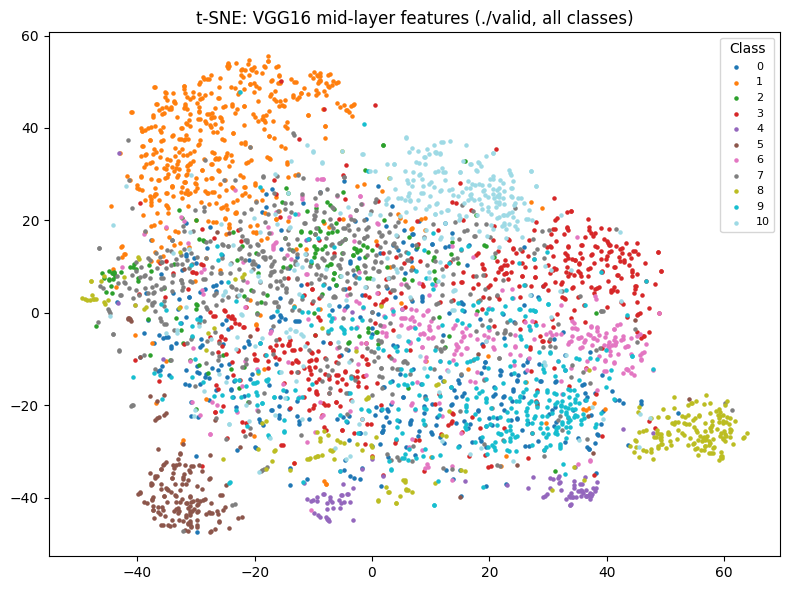

In [22]:
# image 1/2: mid-layer, all 11 classes colored.
mid_features, mid_labels = extract_features(LAYER_INDICES["mid"])
plot_tsne(mid_features, mid_labels, "t-SNE: VGG16 mid-layer features (./valid, all classes)", "q2_tsne_mid.png")

100%|██████████| 57/57 [00:22<00:00,  2.56it/s]


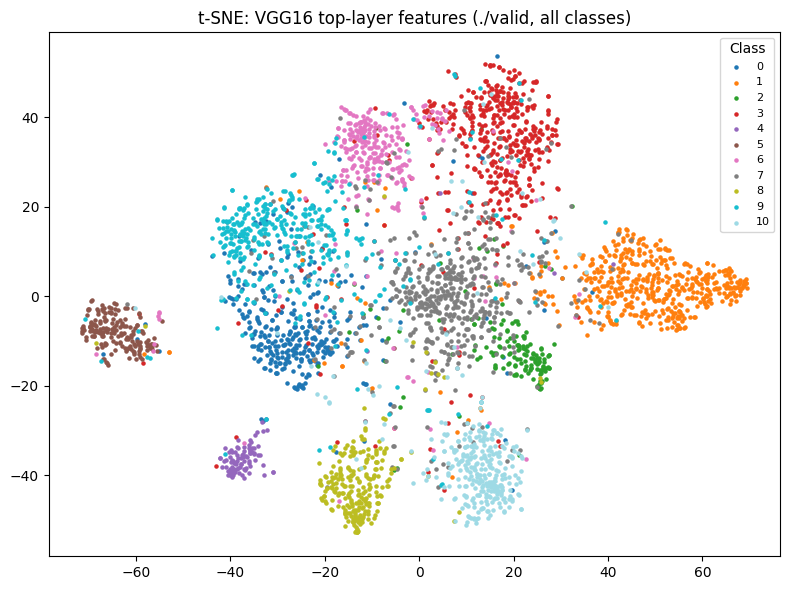

In [23]:
# image 2/2: top-layer, all 11 classes colored.
top_features, top_labels = extract_features(LAYER_INDICES["top"])
plot_tsne(top_features, top_labels, "t-SNE: VGG16 top-layer features (./valid, all classes)", "q2_tsne_top.png")

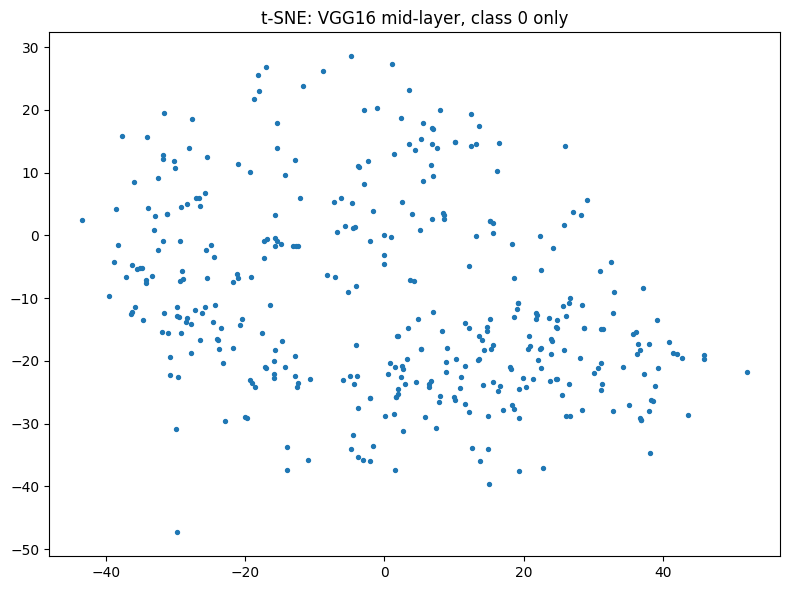

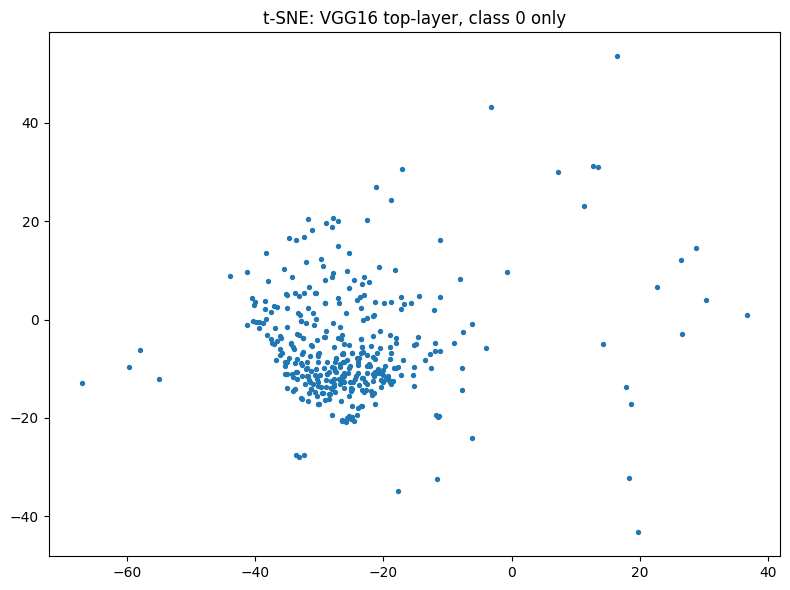

In [24]:
# single-class zoom-in, mid and top layers.
TARGET_LABEL = 0
plot_tsne(mid_features, mid_labels, f"t-SNE: VGG16 mid-layer, class {TARGET_LABEL} only", "q2_tsne_mid_class0.png", target_label=TARGET_LABEL)
plot_tsne(top_features, top_labels, f"t-SNE: VGG16 top-layer, class {TARGET_LABEL} only", "q2_tsne_top_class0.png", target_label=TARGET_LABEL)